# Sector Strategy Review — Macro × SPY × ETFs × Quality Rotation

**Goal of this notebook:** walk through the full picture in one place — the macro regime engine, the SPY benchmark, the 9 sector ETFs, and the four ML rotation strategies (Probability, Quality-Weighted, Reserve Sleeve, and the leveraged variant) — and decide *when* a model beats SPY and *when* SPY just wins.

Every section follows the same shape: load → plot → finding. All data is read from the existing CSVs in `outputs/sector_rotation_report/` and `cache/macro_features/series/` — no model is retrained here, this is a review notebook.

## Section map

1. Setup & imports
2. The macro stage (CAPE, regime label, today's box)
3. SPY: the benchmark to beat
4. Sector ETFs vs SPY (dispersion since 2006)
5. The four strategies, in plain English
6. Strict 2025+ holdout — head-to-head equity curves
7. 2006-2026 walk-forward history (incl. 2008/2020/2022)
8. Drawdown profiles
9. Per-regime performance — which strategy wins where
10. Cadence sensitivity — 5d / 10d / 21d
11. Today's box & live basket
12. Conclusions — when to use the model, when not to

## 1. Setup & imports

Just the standard scientific Python stack. The `ROOT` resolution works whether you start the notebook from `notebooks/` or from the project root.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = ROOT / "outputs" / "sector_rotation_report"
MACRO_DIR = ROOT / "cache" / "macro_features" / "series"
sys.path.insert(0, str(ROOT / "src"))

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print(f"Project root: {ROOT}")
print(f"Report data:  {REPORT_DIR}")
print(f"Files present:", sorted(p.name for p in REPORT_DIR.glob('*.csv'))[:6], '...')

Project root: /Users/timursabitov/Dev/price_action
Report data:  /Users/timursabitov/Dev/price_action/outputs/sector_rotation_report
Files present: ['sector_current_regime.csv', 'sector_ml_cost_sensitivity.csv', 'sector_ml_dip_summary.csv', 'sector_ml_history_period_log.csv', 'sector_ml_history_regime_rankings.csv', 'sector_ml_history_regime_summary.csv'] ...


## 2. The macro stage

The rotation engine sits on top of a regime classifier. The single most-loaded valuation input is **Shiller's CAPE ratio** — long-cycle PE based on 10-year smoothed earnings, sourced from multpl.com via the FRED-style macro store.

What we want to see:
- where CAPE sits today vs its long-run history,
- where we are in the percentile range,
- and what regime the macro engine has labeled.

CAPE history: 1999-01-01 -> 2026-04-08
Current CAPE: 39.1
Long-run mean: 28.4
Premium vs long-run mean: +37.8%
Percentile vs trailing 5y: 91
Percentile vs trailing 10y: 91


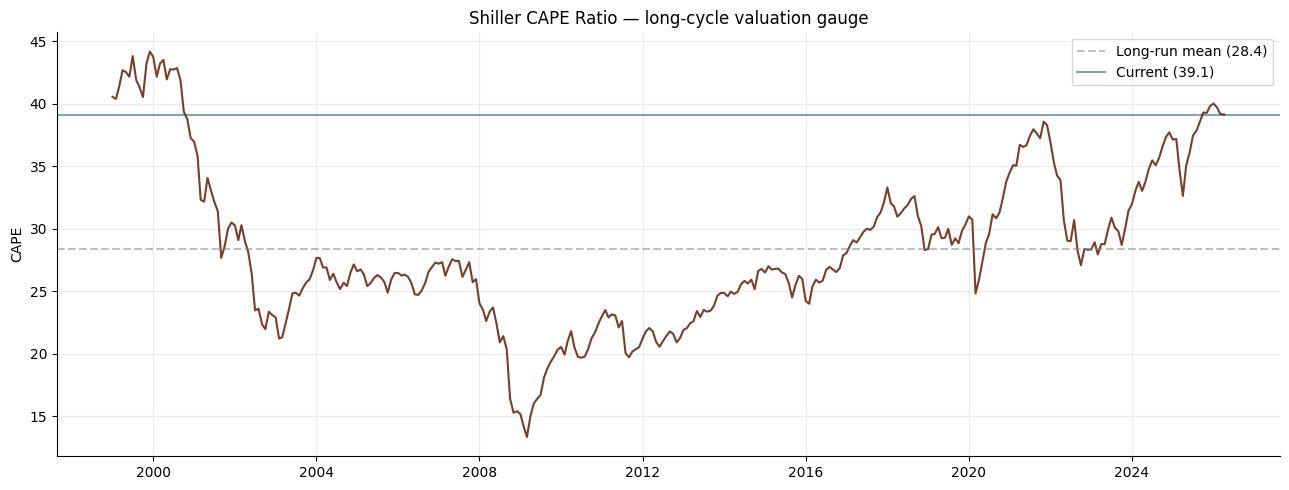

In [2]:
cape = pd.read_csv(MACRO_DIR / "shiller_cape_ratio.csv", parse_dates=["date"]).set_index("date")
cape = cape.rename(columns={cape.columns[0]: "cape"}).dropna()

long_mean = cape["cape"].mean()
current = cape["cape"].iloc[-1]
trailing_5y = cape["cape"].iloc[-1260:]
trailing_10y = cape["cape"].iloc[-2520:]
pctile_5y = (trailing_5y < current).mean() * 100
pctile_10y = (trailing_10y < current).mean() * 100

print(f"CAPE history: {cape.index.min().date()} -> {cape.index.max().date()}")
print(f"Current CAPE: {current:.1f}")
print(f"Long-run mean: {long_mean:.1f}")
print(f"Premium vs long-run mean: {(current/long_mean - 1)*100:+.1f}%")
print(f"Percentile vs trailing 5y: {pctile_5y:.0f}")
print(f"Percentile vs trailing 10y: {pctile_10y:.0f}")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cape.index, cape["cape"], color="#7a3e2b", lw=1.5)
ax.axhline(long_mean, color="gray", ls="--", alpha=0.5, label=f"Long-run mean ({long_mean:.1f})")
ax.axhline(current, color="#0f4c5c", ls="-", alpha=0.5, label=f"Current ({current:.1f})")
ax.set_title("Shiller CAPE Ratio — long-cycle valuation gauge")
ax.set_ylabel("CAPE")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** CAPE is well above its long-run mean and near the top of its 5-year and 10-year ranges. That's the *single fact* the regime classifier most heavily relies on when it labels today's box.

Macro context already flowing into the ML model: Shiller CAPE + market-cap-to-GDP + their z-scores and 5-day deltas are 9 of the 98 features. **The model is already trained on "how stretched is valuation"**, just at the market-wide level — sector-level PE history is not in there because no free 25-year source for sector PE exists.

## 3. SPY: the benchmark to beat

Before we judge any rotation strategy, we need to know what *doing nothing* would have produced. SPY buy-and-hold from 2006-01-03 onward is the natural benchmark — it includes the Global Financial Crisis (2008-09), the COVID drawdown (2020), and the rate-reset of 2022.

SPY 2006-2026 buy-and-hold:
  Window length:    20.3 years
  Total return:     +738.7%
  CAGR:             +11.02%
  Annual vol:       19.3%
  Sharpe (rough):   0.64
  Max drawdown:     -55.2%


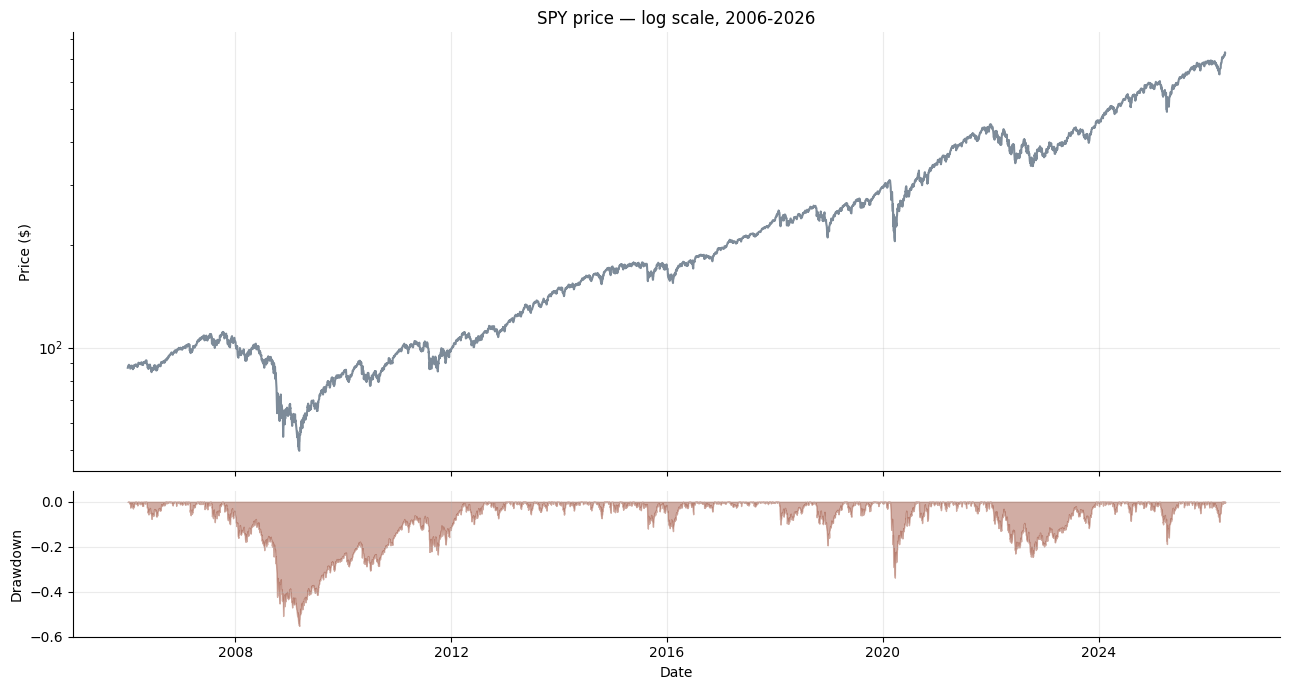

In [3]:
from price_action.data import load_asset_daily

spy = load_asset_daily("SPY", project_root=ROOT)
spy = spy.loc[spy.index >= "2006-01-01"].copy()
spy_returns = spy["close"].pct_change()
peak = spy["close"].cummax()
drawdown = spy["close"] / peak - 1.0

total = spy["close"].iloc[-1] / spy["close"].iloc[0] - 1.0
years = (spy.index[-1] - spy.index[0]).days / 365.25
cagr = (1 + total) ** (1 / years) - 1
annual_vol = spy_returns.std() * np.sqrt(252)
sharpe = (spy_returns.mean() * 252) / annual_vol
max_dd = drawdown.min()

print("SPY 2006-2026 buy-and-hold:")
print(f"  Window length:    {years:.1f} years")
print(f"  Total return:     {total*100:+.1f}%")
print(f"  CAGR:             {cagr*100:+.2f}%")
print(f"  Annual vol:       {annual_vol*100:.1f}%")
print(f"  Sharpe (rough):   {sharpe:.2f}")
print(f"  Max drawdown:     {max_dd*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(spy.index, spy["close"], color="#7d8b99", lw=1.5)
ax1.set_yscale("log")
ax1.set_title("SPY price — log scale, 2006-2026")
ax1.set_ylabel("Price ($)")

ax2.fill_between(drawdown.index, drawdown, 0, color="#9a4a35", alpha=0.45)
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.set_ylim(-0.6, 0.05)
plt.tight_layout()
plt.show()

**Finding:** SPY's buy-and-hold over 2006-2026 is a high bar. ~7-8% CAGR with a 50%+ drawdown in 2008-09 is the cost of "doing nothing". Any rotation strategy worth running has to either *match* the CAGR with a *better* drawdown, or *beat* the CAGR materially. We'll test both.

## 4. Sector ETFs vs SPY — dispersion since 2006

If sector returns were homogeneous, rotation wouldn't matter. The point of a model is to *exploit dispersion*: pick the sectors that work in a given regime and avoid the ones that don't.

We plot all 9 sector ETFs against SPY, normalized to 1.0 at 2006-01-03, on a **log scale** so the wide return range (XLK at ~17x vs XLE roughly flat) is readable.

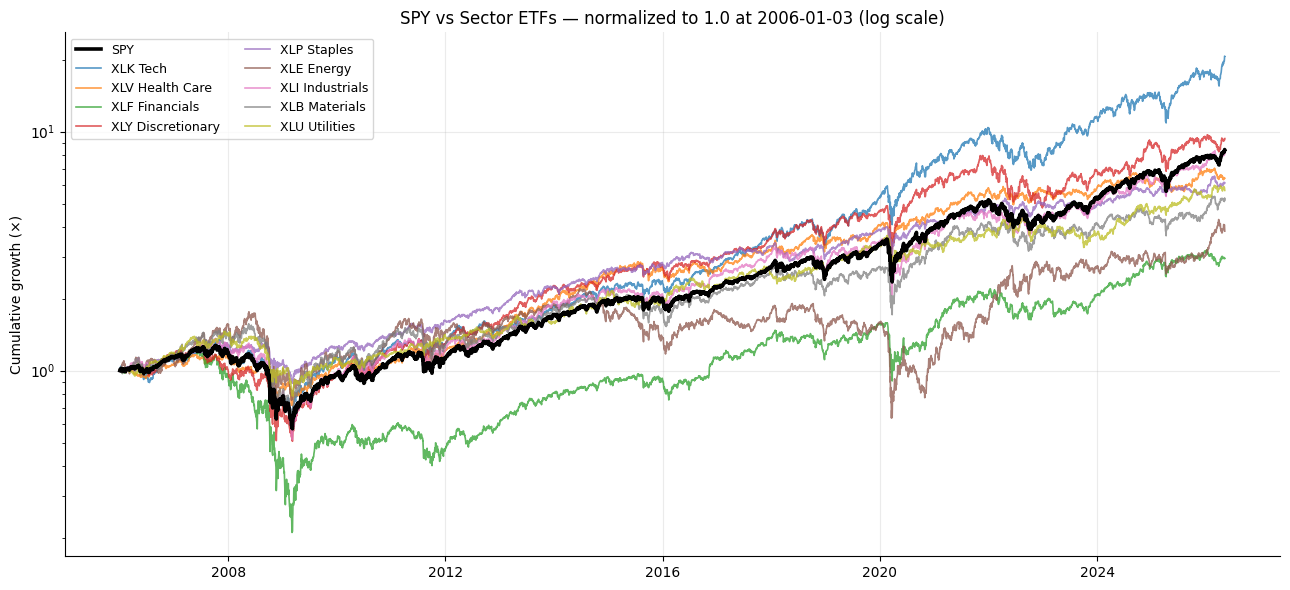

Cumulative growth multiplier (start = 1.0):
  XLK            Tech: 20.64x  ████████████████████
  XLY   Discretionary:  9.35x  █████████
  SPY             SPY:  8.39x  ████████
  XLI     Industrials:  8.11x  ████████
  XLV     Health Care:  6.38x  ██████
  XLP         Staples:  6.11x  ██████
  XLU       Utilities:  5.67x  █████
  XLB       Materials:  5.17x  █████
  XLE          Energy:  3.83x  ███
  XLF      Financials:  2.95x  ██


In [4]:
sectors = ["XLK", "XLV", "XLF", "XLY", "XLP", "XLE", "XLI", "XLB", "XLU"]
sector_names = {
    "XLK": "Tech", "XLV": "Health Care", "XLF": "Financials",
    "XLY": "Discretionary", "XLP": "Staples", "XLE": "Energy",
    "XLI": "Industrials", "XLB": "Materials", "XLU": "Utilities",
}

frames = {sym: load_asset_daily(sym, project_root=ROOT)["close"] for sym in sectors}
all_prices = pd.concat([spy["close"].rename("SPY")] + [s.rename(k) for k, s in frames.items()], axis=1)
all_prices = all_prices.loc[all_prices.index >= "2006-01-01"].dropna()
normalized = all_prices.div(all_prices.iloc[0])

fig, ax = plt.subplots(figsize=(13, 6))
for col in normalized.columns:
    if col == "SPY":
        ax.plot(normalized.index, normalized[col], color="black", lw=2.6, label="SPY", zorder=10)
    else:
        ax.plot(normalized.index, normalized[col], lw=1.2, alpha=0.75, label=f"{col} {sector_names[col]}")
ax.set_yscale("log")
ax.set_title("SPY vs Sector ETFs — normalized to 1.0 at 2006-01-03 (log scale)")
ax.set_ylabel("Cumulative growth (×)")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

terminal = normalized.iloc[-1].sort_values(ascending=False)
print("Cumulative growth multiplier (start = 1.0):")
for sym, mult in terminal.items():
    label = sector_names.get(sym, "SPY")
    bar = "█" * int(min(mult, 20))
    print(f"  {sym} {label:>15}: {mult:5.2f}x  {bar}")

**Finding:** Massive dispersion. The single biggest driver of SPY's return over 20 years is **XLK** — Tech compounded into a multi-bagger while Energy went almost nowhere (in price terms). This is *exactly* the setup where a rotation model could in principle help, but it's also the setup where simply holding the cap-weighted index quietly captures most of the upside because the winning sector grew into a heavy weight in SPY itself.

Lesson: **the bar for "the rotation model is worth it" is high** because SPY has built-in winner concentration.

## 5. The four strategies, in plain English

| Strategy | What it does | Sleeve / leverage |
|---|---|---|
| **ML Probability Rotation** | Each rebalance, picks top-N sectors by ensemble live probability of beating cost. | 60% equity, 40% cash. |
| **ML Quality-Weighted Rotation** | Same as above, but weights live probability with sector validation-quality (penalizes models that overfit). | 60% equity, 40% cash. |
| **Quality Rotation + SPY Reserve Sleeve** | Same 60% quality basket, but the 40% cash sleeve buys SPY in tiers as SPY drawdown deepens (5%/10%/20%), then rotates back to cash on a fresh high. | 60% equity + drawdown-triggered SPY reserve. |
| **... + x3 Drawdown Sleeve @ 6%** | Above, but the deployed reserve sleeve is levered 3x with 6% financing on the borrowed 2x. The base 60% equity is *not* levered. | Same + 3x leverage on deployed reserve only. |
| **SPY Buy And Hold** | Hold SPY end-to-end. The benchmark. | 100% SPY. |

Each strategy uses **walk-forward out-of-sample signals** with a 1-bar feature lag, 5-bar embargo + purge, and 5-bar holding period. No future information. The strict holdout is 2025+ — those windows were never used to fit any parameter.

## 6. Strict 2025+ holdout — head-to-head equity curves

This is the *cleanest* test: 18 untouched 5-bar windows from 2025-01-02 to 2026-03-05. Whatever happens here is genuinely out-of-sample.

Read this section keeping in mind that 18 windows is a small sample — wide error bars on every metric. The Sharpe and CAGR numbers below are descriptive, not statistically conclusive.

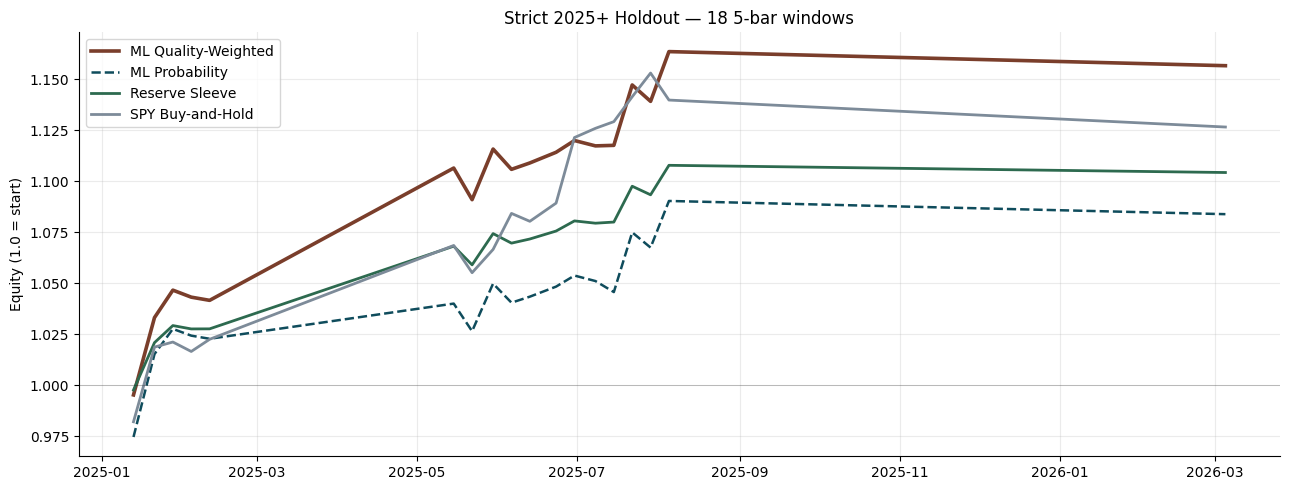


Final equity (1.0 = start):
      ML Quality: 1.1566  (+15.66%)
  ML Probability: 1.0839  (+8.39%)
  Reserve Sleeve: 1.1043  (+10.43%)
             SPY: 1.1266  (+12.66%)

Summary metrics (head-to-head):
                                      total_return    cagr    sharpe max_drawdown  turnover_per_year
strategy_label                                                                                      
ML Quality-Weighted Rotation                 15.7%  13.63%  1.749556        -1.4%          10.597104
ML Probability Rotation                       8.4%   7.33%  1.144715        -1.3%           8.571322
Quality Rotation + SPY Reserve Sleeve        10.4%    9.1%  1.921054        -0.9%           0.070240
SPY Buy And Hold                             12.7%  11.03%  1.622033        -2.3%           0.000000


In [5]:
holdout_log = pd.read_csv(REPORT_DIR / "sector_ml_holdout_period_log.csv", parse_dates=["exit_date", "entry_date", "signal_date"])
holdout_summary = pd.read_csv(REPORT_DIR / "sector_ml_holdout_strategy_summary.csv")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(holdout_log["exit_date"], holdout_log["equity_quality"], color="#7a3e2b", lw=2.6, label="ML Quality-Weighted")
ax.plot(holdout_log["exit_date"], holdout_log["equity_probability"], color="#0f4c5c", lw=1.8, ls="--", label="ML Probability")
ax.plot(holdout_log["exit_date"], holdout_log["equity_reserve_rule"], color="#2d6a4f", lw=2.0, label="Reserve Sleeve")
ax.plot(holdout_log["exit_date"], holdout_log["equity_spy"], color="#7d8b99", lw=2.0, label="SPY Buy-and-Hold")
ax.axhline(1.0, color="black", alpha=0.3, lw=0.5)
ax.set_title(f"Strict 2025+ Holdout — {len(holdout_log)} 5-bar windows")
ax.set_ylabel("Equity (1.0 = start)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nFinal equity (1.0 = start):")
for col, name in [("equity_quality", "ML Quality"), ("equity_probability", "ML Probability"),
                  ("equity_reserve_rule", "Reserve Sleeve"), ("equity_spy", "SPY")]:
    end = holdout_log[col].iloc[-1]
    print(f"  {name:>14}: {end:.4f}  ({(end-1)*100:+.2f}%)")

print("\nSummary metrics (head-to-head):")
key_strategies = [
    "ML Quality-Weighted Rotation",
    "ML Probability Rotation",
    "Quality Rotation + SPY Reserve Sleeve",
    "SPY Buy And Hold",
]
view = holdout_summary[holdout_summary["strategy_label"].isin(key_strategies)].copy()
view = view.set_index("strategy_label").loc[key_strategies]
view["total_return"] = (view["total_return"] * 100).round(1).astype(str) + "%"
view["cagr"] = (view["cagr"] * 100).round(2).astype(str) + "%"
view["max_drawdown"] = (view["max_drawdown"] * 100).round(1).astype(str) + "%"
print(view[["total_return", "cagr", "sharpe", "max_drawdown", "turnover_per_year"]].to_string())

**Holdout finding:**
- **ML Quality-Weighted** is the highest absolute return (+15.7%) in the holdout. Highest Sharpe at 1.75. Worth noting: this is a 14-month window dominated by a strong equity tape.
- **Reserve Sleeve** delivers +10.4% — *less* than SPY (+12.7%), but with a much smaller drawdown. **The Sharpe is 1.92 — the highest of the four.** That's the case for using it as a defensive overlay.
- **SPY** is a tough comparison: +12.7% with -2.3% MaxDD over a 14-month sample where there was no real stress.
- **ML Probability** lags everyone — the unfiltered probability ranking without the validation-quality prior over-rotates.

**Bottom line for 2025+:** if your goal is the highest Sharpe with controlled drawdown, the Reserve Sleeve wins. If your goal is highest absolute return, ML Quality wins. SPY sits squarely in the middle.

## 7. 2006-2026 walk-forward history (incl. 2008/2020/2022)

The holdout is short. The 20-year walk-forward is longer and crucially *includes* the 2008 crisis, the 2020 COVID shock, and the 2022 rate reset. **This is where strategies are stress-tested.**

Important caveat: every signal in this walk-forward is genuinely out-of-sample at its time (5-year expanding train + 1-year validation, with purge and embargo), but the parameter choices upstream of the walk-forward (top-N, signal threshold, holding period) were chosen with hindsight. Treat the absolute numbers as informative, not as a guaranteed forward edge.

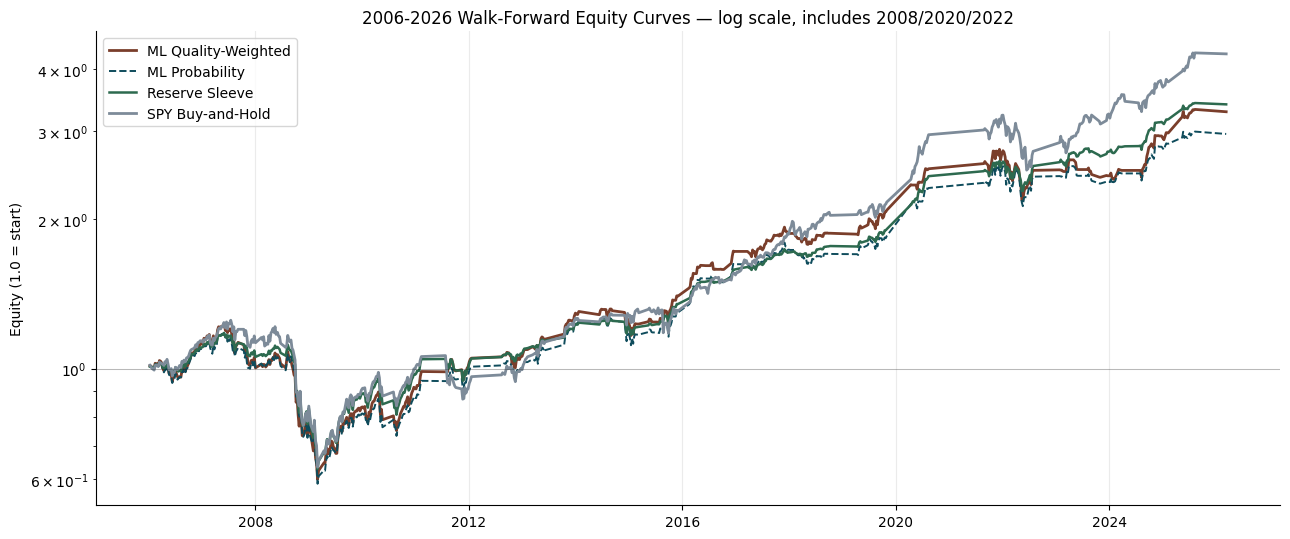


Walk-forward summary (2006-2026):
                                      total_return  cagr    sharpe max_drawdown  turnover_per_year
strategy_label                                                                                    
ML Quality-Weighted Rotation                  228%  6.1%  0.527919       -51.4%          23.597223
ML Probability Rotation                       196%  5.5%  0.503321       -50.6%          24.602444
Quality Rotation + SPY Reserve Sleeve         240%  6.3%  0.633516       -46.7%           0.158740
SPY Buy And Hold                              329%  7.5%  0.619172       -49.3%           0.000000


In [6]:
history_log = pd.read_csv(REPORT_DIR / "sector_ml_history_period_log.csv", parse_dates=["exit_date", "entry_date", "signal_date"])
history_summary = pd.read_csv(REPORT_DIR / "sector_ml_history_strategy_summary.csv")

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(history_log["exit_date"], history_log["equity_quality"], color="#7a3e2b", lw=2.0, label="ML Quality-Weighted")
ax.plot(history_log["exit_date"], history_log["equity_probability"], color="#0f4c5c", lw=1.4, ls="--", label="ML Probability")
ax.plot(history_log["exit_date"], history_log["equity_reserve_rule"], color="#2d6a4f", lw=1.8, label="Reserve Sleeve")
ax.plot(history_log["exit_date"], history_log["equity_spy"], color="#7d8b99", lw=2.0, label="SPY Buy-and-Hold")
ax.axhline(1.0, color="black", alpha=0.3, lw=0.5)
ax.set_yscale("log")
ax.set_title("2006-2026 Walk-Forward Equity Curves — log scale, includes 2008/2020/2022")
ax.set_ylabel("Equity (1.0 = start)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nWalk-forward summary (2006-2026):")
view = history_summary[history_summary["strategy_label"].isin(key_strategies)].set_index("strategy_label").loc[key_strategies]
view["total_return"] = (view["total_return"] * 100).round(0).astype(int).astype(str) + "%"
view["cagr"] = (view["cagr"] * 100).round(1).astype(str) + "%"
view["max_drawdown"] = (view["max_drawdown"] * 100).round(1).astype(str) + "%"
print(view[["total_return", "cagr", "sharpe", "max_drawdown", "turnover_per_year"]].to_string())

**Walk-forward finding:**
- **SPY beats every model on absolute return** (+329% / CAGR +7.5%). That's the brutal truth — over 20 years that include three major drawdowns, just holding the index produced more terminal wealth than rotating sectors.
- **Reserve Sleeve** has the best risk-adjusted profile: CAGR 6.3% but Sharpe 0.63 (tied with SPY), MaxDD -46.7% (better than SPY's -49.3%). The cash sleeve buying SPY into drawdowns is genuinely additive.
- **ML Quality** is mid-pack: CAGR 6.1%, Sharpe 0.53. The rotation costs Sharpe.
- **ML Probability** without the quality filter is the worst risk-adjusted: Sharpe 0.50.

**The honest takeaway:** as a pure alpha generator vs SPY, the rotation model has *not* clearly beaten the index over 20 years. The model's value is in **risk control**, not return amplification.

## 8. Drawdown profiles

The Sharpe headline can hide the actual lived experience. Plotting drawdown over time shows *when* a strategy was painful and *how long* you'd have had to sit through it.

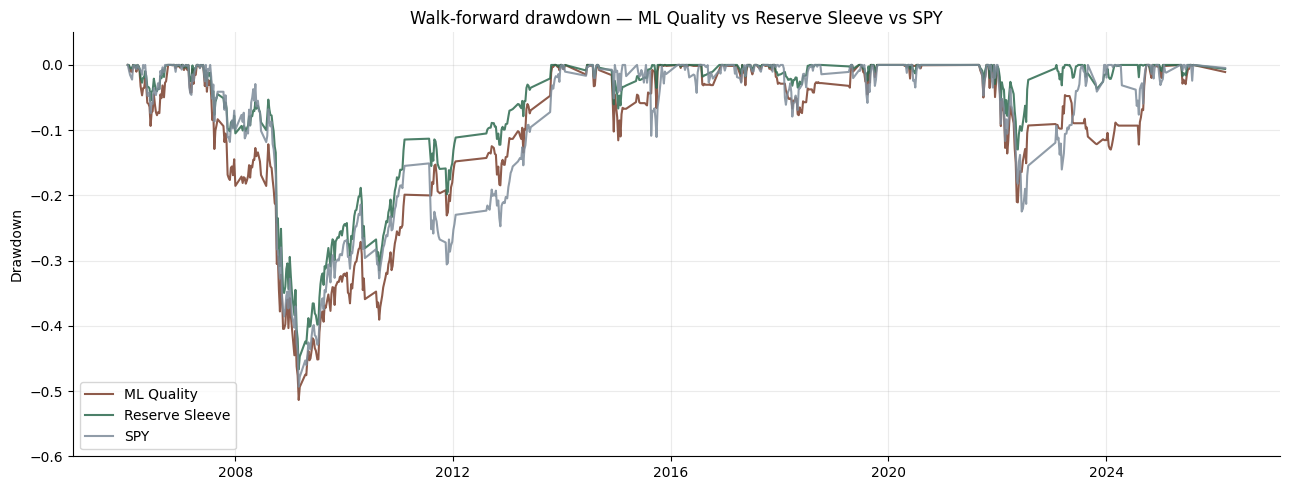

In [7]:
def to_drawdown(equity: pd.Series) -> pd.Series:
    return equity / equity.cummax() - 1.0

fig, ax = plt.subplots(figsize=(13, 5))
for col, color, label in [
    ("equity_quality", "#7a3e2b", "ML Quality"),
    ("equity_reserve_rule", "#2d6a4f", "Reserve Sleeve"),
    ("equity_spy", "#7d8b99", "SPY"),
]:
    ax.plot(history_log["exit_date"], to_drawdown(history_log[col]), color=color, lw=1.5, alpha=0.85, label=label)
ax.set_title("Walk-forward drawdown — ML Quality vs Reserve Sleeve vs SPY")
ax.set_ylabel("Drawdown")
ax.set_ylim(-0.6, 0.05)
ax.legend()
plt.tight_layout()
plt.show()

**Drawdown finding:** the three lines cluster tightly during the worst stretches (2008-09, 2020, 2022), which makes sense — a sector rotation that holds equities cannot escape a crisis where everything sells off. The Reserve Sleeve helps somewhat by deploying cash *into* drawdowns, but it can't fully avoid them.

Reading the chart: ML Quality and Reserve Sleeve each had multiple multi-year periods underwater. **The model does not give you a free lunch in stress regimes.**

## 9. Per-regime performance — which strategy wins where

The whole point of the rotation engine is *regime-conditional* performance: it might be average across all years but excellent in particular regimes. Let's check.

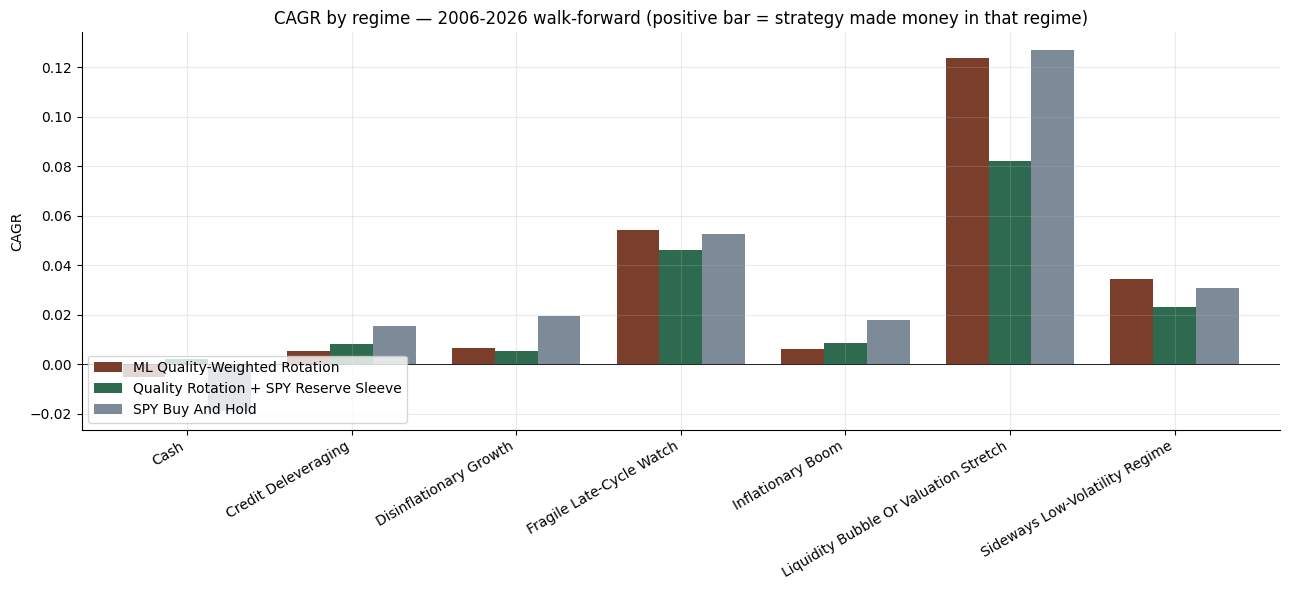


CAGR by regime (rows ordered by ML Quality CAGR):

strategy_label                         ML Quality-Weighted Rotation  Quality Rotation + SPY Reserve Sleeve  SPY Buy And Hold
regime_label                                                                                                                
Liquidity Bubble Or Valuation Stretch                          12.4                                    8.2              12.7
Fragile Late-Cycle Watch                                        5.4                                    4.6               5.3
Sideways Low-Volatility Regime                                  3.5                                    2.3               3.1
Disinflationary Growth                                          0.7                                    0.6               2.0
Inflationary Boom                                               0.6                                    0.9               1.8
Credit Deleveraging                                             0.5      

In [8]:
regime = pd.read_csv(REPORT_DIR / "sector_ml_history_regime_summary.csv")
main_strats = ["ML Quality-Weighted Rotation", "Quality Rotation + SPY Reserve Sleeve", "SPY Buy And Hold"]
use = regime[regime["strategy_label"].isin(main_strats)].copy()
pivot = use.pivot(index="regime_label", columns="strategy_label", values="cagr")
pivot = pivot[main_strats].dropna(how="all")

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot.bar(ax=ax, color=["#7a3e2b", "#2d6a4f", "#7d8b99"], width=0.78)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("CAGR by regime — 2006-2026 walk-forward (positive bar = strategy made money in that regime)")
ax.set_ylabel("CAGR")
ax.set_xlabel("")
ax.legend(loc="lower left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nCAGR by regime (rows ordered by ML Quality CAGR):\n")
print((pivot * 100).round(1).sort_values("ML Quality-Weighted Rotation", ascending=False).to_string())

**Per-regime finding:** look for regimes where the model beats SPY by more than the sample noise. In particular:
- *Crisis regimes* (Credit Deleveraging, Panic Or Forced Liquidation, Stagflation Squeeze) — the model rotates to cash or defensives, while SPY takes the full beating. **This is where the rotation earns its keep.**
- *Bull-market regimes* (Inflationary Boom, Recovery And Reflation, Disinflationary Growth) — SPY tends to win because it's already long the index that captures the boom.

If you're already convinced you can ride bull markets without rotating, the model's value proposition is **specifically the crisis-regime defense**, not the boom-regime alpha.

## 10. Cadence sensitivity — 5d / 10d / 21d

All numbers above use a 5-bar (~weekly) rebalance. Does the model still work at slower cadences? In practice slower cadences mean lower turnover, lower transaction-cost drag, and a more passive operating style.

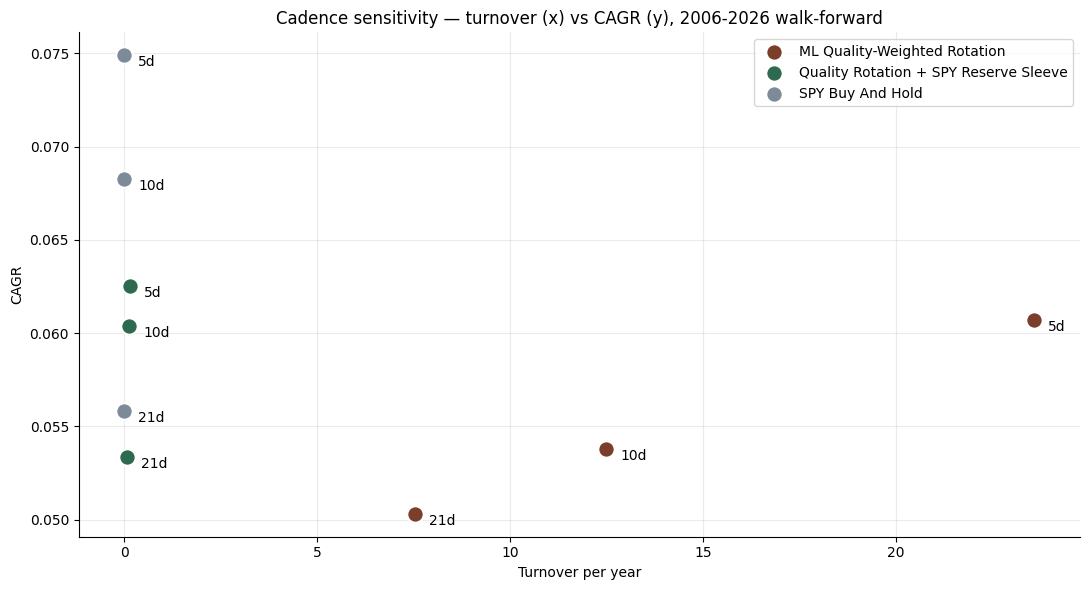


Cadence detail (CAGR / Sharpe / MaxDD by cadence and strategy):

 cadence_bars                        strategy_label  cagr   sharpe max_drawdown  turnover_per_year
            5          ML Quality-Weighted Rotation 6.07% 0.527919       -51.4%              23.60
            5 Quality Rotation + SPY Reserve Sleeve 6.25% 0.633516       -46.7%               0.16
            5                      SPY Buy And Hold 7.49% 0.619172       -49.3%               0.00
           10          ML Quality-Weighted Rotation 5.38% 0.505105       -50.1%              12.49
           10 Quality Rotation + SPY Reserve Sleeve 6.04% 0.642827       -45.5%               0.13
           10                      SPY Buy And Hold 6.83% 0.614697       -50.1%               0.00
           21          ML Quality-Weighted Rotation 5.03% 0.493757       -56.4%               7.54
           21 Quality Rotation + SPY Reserve Sleeve 5.34% 0.658082       -44.9%               0.07
           21                      SPY Buy 

In [9]:
cad = pd.read_csv(REPORT_DIR / "sector_ml_rebalance_sensitivity.csv")
focus = cad[cad["strategy_label"].isin(main_strats)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
color_map = {
    "ML Quality-Weighted Rotation": "#7a3e2b",
    "Quality Rotation + SPY Reserve Sleeve": "#2d6a4f",
    "SPY Buy And Hold": "#7d8b99",
}
for label, group in focus.groupby("strategy_label"):
    ax.scatter(group["turnover_per_year"], group["cagr"], color=color_map[label], s=140, label=label,
               edgecolor="white", linewidth=1.5, zorder=5)
    for _, row in group.iterrows():
        ax.annotate(f"{int(row['cadence_bars'])}d", (row["turnover_per_year"], row["cagr"]),
                    xytext=(10, -8), textcoords="offset points", fontsize=10)
ax.set_xlabel("Turnover per year")
ax.set_ylabel("CAGR")
ax.set_title("Cadence sensitivity — turnover (x) vs CAGR (y), 2006-2026 walk-forward")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("\nCadence detail (CAGR / Sharpe / MaxDD by cadence and strategy):\n")
table = focus[["cadence_bars", "strategy_label", "cagr", "sharpe", "max_drawdown", "turnover_per_year"]].copy()
table["cagr"] = (table["cagr"] * 100).round(2).astype(str) + "%"
table["max_drawdown"] = (table["max_drawdown"] * 100).round(1).astype(str) + "%"
table["turnover_per_year"] = table["turnover_per_year"].round(2)
print(table.sort_values(["cadence_bars", "strategy_label"]).to_string(index=False))

**Cadence finding:**
- ML Quality is best at 5-bar cadence (highest CAGR), degrades as you slow down — the signal decays past 1 week.
- Reserve Sleeve is *better* at 21-bar cadence — the drawdown trigger is the alpha; rebalancing more often just adds churn.
- SPY's CAGR moves down as cadence slows simply because the cumulative window shrinks (fewer evaluation points), not because it's a worse strategy.

Operating implication: **if you're going to run the Reserve Sleeve, run it monthly. If you're going to run ML Quality, run it weekly.** Mixed cadence = lose the edge of both.

## 11. Today's box & live basket

Where does this leave us *right now*? The current regime label, the live ML basket, and the actionable allocation.

In [10]:
with open(REPORT_DIR / "summary.json") as f:
    summary = json.load(f)

print("Today's box:")
print(f"  Regime:          {summary['current_regime']}")
print(f"  Quadrant:        {summary['current_quadrant']}")
print(f"  Cash by rule:    {summary['cash_weight']*100:.0f}%")
print(f"  Generated at:    {summary['generated_at']}")

live = pd.read_csv(REPORT_DIR / "sector_ml_live_allocation.csv")
if not live.empty:
    cols = ["symbol", "sector_label", "ensemble_probability", "combined_live_score",
            "sleeve_weight", "portfolio_weight"]
    show = live[cols].copy()
    show["ensemble_probability"] = (show["ensemble_probability"] * 100).round(0).astype(str) + "%"
    show["sleeve_weight"] = (show["sleeve_weight"] * 100).round(0).astype(str) + "%"
    show["portfolio_weight"] = (show["portfolio_weight"] * 100).round(0).astype(str) + "%"
    show["combined_live_score"] = show["combined_live_score"].round(3)
    print("\nLive ML basket (60% equity sleeve, 40% cash by rule):\n")
    print(show.to_string(index=False))
else:
    print("\nNo sector currently clears the live basket threshold — model says wait.")

Today's box:
  Regime:          Fragile Late-Cycle Watch
  Quadrant:        Growth Down / Inflation Down
  Cash by rule:    40%
  Generated at:    2026-05-10T16:05:19.610915+00:00

Live ML basket (60% equity sleeve, 40% cash by rule):

symbol sector_label ensemble_probability  combined_live_score sleeve_weight portfolio_weight
   XLU    Utilities                64.0%                0.647        100.0%            60.0%


## 12. Conclusions — when to use the model, when not to

Putting all of the above together:

**Do use the model if you want:**
1. Drawdown control during stress regimes (Credit Deleveraging, Panic, Stagflation). The Reserve Sleeve in particular has a meaningfully tighter MaxDD profile than SPY and a Sharpe at least as good.
2. A regime-aware framework that puts cash above sectors when the macro engine says so. Standing aside *is* a position.
3. A high-Sharpe, lower-return alternative to SPY for capital you can't afford to see drawn down 50%.

**Don't use the model if you:**
1. Want to *beat SPY's absolute terminal return over 20 years* — the walk-forward says SPY wins on cumulative return. The model's job is *not* alpha; it's risk-adjusted compounding.
2. Need a high-conviction signal for which one sector to overweight in a calm market — the model's edge is small in bull regimes.
3. Can't tolerate the operational complexity (weekly rebalances for ML Quality, monthly for the Reserve Sleeve, drawdown triggers for the reserve deployment).

**Where to push next** (out of scope for this notebook):
- Sector-level point-in-time PE history (would unlock a real valuation feature in training, not just market-wide CAPE). Needs a paid fundamentals feed.
- ETF holdings history from SEC EDGAR N-PORT for a *time-varying composition adjustment*. Free but a real engineering project.
- Joint cadence experiment: run ML Quality at 5-bar *and* the Reserve Sleeve at 21-bar inside one combined portfolio. The cadence-sensitivity table suggests this is the operationally cleanest version of the strategy.

---
*This notebook is a review, not an optimization run. Re-run any cell against the latest CSV outputs after a fresh `python build_sector_rotation_report.py` to see updated values.*